In [1]:
import pickle, os

!rm -rf PGST
!git clone --quiet https://github.com/mickdeines/PGST/
os.chdir("PGST")

BUNDLE_PATH = os.path.join("viewer_bundle_CY2024.pkl")
with open(BUNDLE_PATH, "rb") as f:
    payload = pickle.load(f)

df = payload["df"]
HEATING_EQUIPMENT = payload["HEATING_EQUIPMENT"]
NON_HEATING_EQUIPMENT = payload["NON_HEATING_EQUIPMENT"]
ANALYSIS_YEAR = payload["ANALYSIS_YEAR"]
ANALYSIS_YEARS = payload["ANALYSIS_YEARS"]

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# DROP-IN: Interactive per-device hourly Btu/hr load profile viewer
# Requires: df, HEATING_EQUIPMENT, NON_HEATING_EQUIPMENT, ANALYSIS_YEAR
#           (all defined in the cells above)
# ─────────────────────────────────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# ── Build device registry ────────────────────────────────────────────────────
_warm_colors = ["tab:orange", "#e65100", "#ff7f0e", "#ff6b6b"]
_cool_colors = ["tab:blue",   "#4fc3f7", "#2ca02c", "#66bb6a", "#0097a7"]

_devices = {}
for _wi, (uid, p) in enumerate(HEATING_EQUIPMENT.items()):
    col = f"heat_btu_in_{uid}"
    if col in df.columns:
        _devices[p["name"]] = {"col": col, "color": _warm_colors[_wi % len(_warm_colors)]}

for _ci, (uid, p) in enumerate(NON_HEATING_EQUIPMENT.items()):
    col = f"nonheat_btu_in_{uid}"
    if col in df.columns:
        _devices[p["name"]] = {"col": col, "color": _cool_colors[_ci % len(_cool_colors)]}

_yr_start = df.index.min().normalize()
_yr_end   = df.index.max().normalize()

# ── Widgets ──────────────────────────────────────────────────────────────────
_dd = widgets.Dropdown(
    options=list(_devices.keys()),
    description="Device:",
    style={"description_width": "60px"},
    layout=widgets.Layout(width="380px"),
)
_dp_s = widgets.DatePicker(
    description="Start:",
    value=pd.Timestamp(f"{ANALYSIS_YEAR}-01-01").date(),   # _dp_s
    style={"description_width": "48px"},
    layout=widgets.Layout(width="210px"),
)
_dp_e = widgets.DatePicker(
    description="End:",
    value=pd.Timestamp(f"{ANALYSIS_YEAR}-12-31").date(),   # _dp_e
    style={"description_width": "48px"},
    layout=widgets.Layout(width="210px"),
)

_btn_style = dict(layout=widgets.Layout(width="82px", height="28px"))
_btn_1d  = widgets.Button(description="1 Day",    **_btn_style)
_btn_1w  = widgets.Button(description="1 Week",   **_btn_style)
_btn_1m  = widgets.Button(description="1 Month",  **_btn_style)
_btn_yr = widgets.Button(description="All Years", button_style="", layout=widgets.Layout(width="90px", height="28px"))

_year_btns = [
    widgets.Button(
        description=str(y),
        button_style="info" if y == ANALYSIS_YEAR else "",
        layout=widgets.Layout(width="70px", height="28px")
    )
    for y in ANALYSIS_YEARS
]

def _zoom_to_year(y, btn):
    def _cb(_):
        for b in _year_btns:
            b.button_style = ""
        _btn_yr.button_style = ""
        btn.button_style = "info"
        _dp_s.value = pd.Timestamp(f"{y}-01-01").date()
        _dp_e.value = pd.Timestamp(f"{y}-12-31").date()
        _replot()
    return _cb

for y, btn in zip(ANALYSIS_YEARS, _year_btns):
    btn.on_click(_zoom_to_year(y, btn))  # pass btn too

_out = widgets.Output()

# ── Plot function ─────────────────────────────────────────────────────────────
def _replot(*_):
    info = _devices[_dd.value]
    col  = info["col"]

    try:
        start = pd.Timestamp(_dp_s.value, tz="America/Los_Angeles")
        end   = pd.Timestamp(_dp_e.value, tz="America/Los_Angeles") + pd.Timedelta(hours=23)
    except Exception:
        return
    if start >= end:
        return

    dslice = df.loc[(df.index >= start) & (df.index <= end), col]
    dslice.index = dslice.index.tz_localize(None)
    n_hrs  = len(dslice)

    # adaptive tick format
    if n_hrs <= 48:
        fmt = mdates.DateFormatter("%b %d %H:%M")
        loc = mdates.HourLocator(interval=max(1, n_hrs // 10))
    elif n_hrs <= 24 * 10:
        fmt = mdates.DateFormatter("%a %b %d")
        loc = mdates.DayLocator()
    elif n_hrs <= 24 * 60:
        fmt = mdates.DateFormatter("%b %d")
        loc = mdates.WeekdayLocator(interval=1)
    else:
        fmt = mdates.DateFormatter("%b")
        loc = mdates.MonthLocator()

    peak = dslice.max() if len(dslice) and dslice.max() > 0 else 1.0

    with _out:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(14, 5))

        ax.fill_between(dslice.index, dslice.values,
                        alpha=0.75, color=info["color"], label=_dd.value)

        ax.set_title(
            f"{_dd.value}  —  Hourly Load Profile    {_dp_s.value} – {_dp_e.value}",
            fontsize=12, fontweight="bold",
        )
        ax.set_ylabel("Btu / hr")
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f"{v:,.0f}")
        )

        ax.xaxis.set_major_formatter(fmt)
        ax.xaxis.set_major_locator(loc)
        plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

        ax.set_xlim(start.replace(tzinfo=None), end.replace(tzinfo=None))
        ax.set_ylim(0, peak * 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right", fontsize=10)
        plt.tight_layout()
        plt.show()

# ── Quick-zoom button callbacks ───────────────────────────────────────────────
def _zoom(days):
    def _cb(_):
        end_v = _dp_e.value
        _dp_s.value = (pd.Timestamp(end_v) - pd.Timedelta(days=days)).date()
        _replot()
    return _cb

def _zoom_yr(_):
    for b in _year_btns:
        b.button_style = ""
    _btn_yr.button_style = "primary"
    _dp_s.value = _yr_start.date()
    _dp_e.value = _yr_end.date()
    _replot()

_btn_1d.on_click(_zoom(1))
_btn_1w.on_click(_zoom(7))
_btn_1m.on_click(_zoom(30))
_btn_yr.on_click(_zoom_yr)

# ── Observe changes ───────────────────────────────────────────────────────────
for _w in (_dd, _dp_s, _dp_e):
    _w.observe(_replot, names="value")

# ── Layout & render ───────────────────────────────────────────────────────────
display(
    widgets.VBox([
        _dd,
        widgets.HBox([_dp_s, _dp_e]),
        widgets.HBox([_btn_1d, _btn_1w, _btn_1m, _year_btns[0], _year_btns[1], _year_btns[2], _btn_yr],
                 layout=widgets.Layout(margin="4px 0 8px 0")),
        _out,
    ])
)
_replot()

In [3]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

BUNDLE_PATH = os.path.join("pie_bundle_CY2024.pkl")
with open(BUNDLE_PATH, "rb") as f:
    payload = pickle.load(f)

pie_df_all_years = payload["pie_df_all_years"]
ANALYSIS_YEARS   = payload["ANALYSIS_YEARS"]
warm_colors      = payload["warm_colors"]
cool_colors      = payload["cool_colors"]

def _colors_for_devices(pie_df: pd.DataFrame):
    colors = []
    hi = ni = 0
    for _, r in pie_df.iterrows():
        if r["category"] == "heating":
            colors.append(warm_colors[hi % len(warm_colors)])
            hi += 1
        else:
            colors.append(cool_colors[ni % len(cool_colors)])
            ni += 1
    return colors

KGCO2E_PER_GAL_PROPANE = 5.72
pie_df_all_years["annual_tco2e"] = (
    pie_df_all_years["annual_gal"].astype(float) * KGCO2E_PER_GAL_PROPANE / 1000.0
)

In [4]:
# =============================================================================
# B) MODIFIED PIE CHART CELL (plotting notebook)
# -----------------------------------------------------------------------------
# Loads pie bundle and adds a toggle: Broken vs Fixed controls.
# Fixed controls only changes the boiler annual gallons/tCO2e; all other devices
# remain as in the modeled allocation.
# =============================================================================

import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

BUNDLE_PATH = os.path.join("pie_bundle_CY2024.pkl")
with open(BUNDLE_PATH, "rb") as f:
    payload = pickle.load(f)

pie_df_all_years = payload["pie_df_all_years"].copy()
ANALYSIS_YEARS   = payload["ANALYSIS_YEARS"]
warm_colors      = payload["warm_colors"]
cool_colors      = payload["cool_colors"]

boiler_fixed_controls_annual_gal = payload.get("boiler_fixed_controls_annual_gal", {})
boiler_unit_id = payload.get("boiler_unit_id", "unit_1")

def _colors_for_devices(pie_df: pd.DataFrame):
    colors = []
    hi = ni = 0
    for _, r in pie_df.iterrows():
        if r["category"] == "heating":
            colors.append(warm_colors[hi % len(warm_colors)])
            hi += 1
        else:
            colors.append(cool_colors[ni % len(cool_colors)])
            ni += 1
    return colors

KGCO2E_PER_GAL_PROPANE = 5.72

def _apply_controls_mode(pie_df: pd.DataFrame, selection, controls_mode: str):
    """Return a pie_df with annual_gal (and annual_tco2e) adjusted for controls mode."""
    out = pie_df.copy()

    # ensure annual_tco2e exists
    out["annual_tco2e"] = out["annual_gal"].astype(float) * KGCO2E_PER_GAL_PROPANE / 1000.0

    if controls_mode != "fixed":
        return out

    # fixed controls: overwrite boiler annual_gal for the selected year(s)
    if selection == "avg_2023_2025":
        years = [2023, 2024, 2025]
        vals = [float(boiler_fixed_controls_annual_gal.get(int(y), np.nan)) for y in years]
        vals = [v for v in vals if np.isfinite(v)]
        if not vals:
            raise ValueError("Fixed-controls toggle selected, but boiler_fixed_controls_annual_gal is missing for 2023–2025.")
        boiler_gal = float(np.mean(vals))

        # out here is already aggregated (device/category) in the caller; we will overwrite by unit_id if present
        if "unit_id" in out.columns:
            m = out["unit_id"].astype(str) == str(boiler_unit_id)
        else:
            m = out["device"].astype(str).str.lower().eq("boiler")

        out.loc[m, "annual_gal"] = boiler_gal
        out.loc[m, "annual_tco2e"] = boiler_gal * KGCO2E_PER_GAL_PROPANE / 1000.0
        return out

    # single year
    year = int(selection)
    if int(year) not in {int(k) for k in boiler_fixed_controls_annual_gal.keys()}:
        raise ValueError(f"Fixed-controls toggle selected, but boiler_fixed_controls_annual_gal missing for year {year}.")

    boiler_gal = float(boiler_fixed_controls_annual_gal[int(year)])

    if "unit_id" in out.columns:
        m = out["unit_id"].astype(str) == str(boiler_unit_id)
    else:
        m = out["device"].astype(str).str.lower().eq("boiler")

    out.loc[m, "annual_gal"] = boiler_gal
    out.loc[m, "annual_tco2e"] = boiler_gal * KGCO2E_PER_GAL_PROPANE / 1000.0
    return out


YEARS = [2023, 2024, 2025]

def _plot_ghg_pies(selection, metric="emissions", controls_mode="broken"):
    """metric: 'emissions' -> tCO2e  |  'gallons' -> annual_gal"""
    FORCE_SMALL = {"Admin Kitchen Stove", "ECC Domestic Hot Water"}

    # ── select / aggregate data ──────────────────────────────────────────────
    if selection == "avg_2023_2025":
        pie_df = pie_df_all_years[pie_df_all_years["year"].isin(YEARS)].copy()
        pie_df = (
            pie_df.groupby(["unit_id", "device", "category"], as_index=False)
                  .agg(annual_gal=("annual_gal", "mean"))
        )
        title_suffix = "Average 2023–2025"
    else:
        year = int(selection)
        pie_df = pie_df_all_years[pie_df_all_years["year"] == year].copy()
        title_suffix = f"{year}"

    # apply controls mode (overwrites boiler annual_gal if fixed)
    pie_df = _apply_controls_mode(pie_df, selection=selection, controls_mode=controls_mode)

    # ── metric-specific config ───────────────────────────────────────────────
    if metric == "gallons":
        val_col   = "annual_gal"
        unit      = "gal"
        fmt_val   = lambda v: f"{v:,.0f}"
        title_kw  = "Propane Usage (Gallons)"
    else:
        val_col   = "annual_tco2e"
        unit      = "tCO2e"
        fmt_val   = lambda v: f"{v:,.2g}"
        title_kw  = "Propane Emissions"

    pie_df = pie_df.sort_values(["category", val_col], ascending=[True, False]).reset_index(drop=True)

    values = pie_df[val_col].values
    total  = float(pie_df[val_col].sum())

    # ── 1) detailed device pie ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 8))
    colors = _colors_for_devices(pie_df)

    wedges, texts, autotexts = ax.pie(
        values,
        labels=pie_df["device"].values,
        colors=colors,
        autopct=lambda p: (
            f"{p:.1f}%\n({fmt_val(p / 100 * total)} {unit})" if total > 0 else "0.0%"
        ),
        startangle=140,
        pctdistance=0.75,
        wedgeprops=dict(edgecolor="white", linewidth=1.5),
    )

    SHIFT_UP = {"ECC Stove": 0.035}

    for i, dev in enumerate(pie_df["device"].tolist()):
        if total <= 0:
            continue

        dy = SHIFT_UP.get(dev, 0.0)

        if dy != 0.0:
            x, y = texts[i].get_position()
            texts[i].set_position((x, y + dy))
            x, y = autotexts[i].get_position()
            autotexts[i].set_position((x, y + dy))

        if dev in FORCE_SMALL:
            pct  = 100.0 * float(pie_df.loc[i, val_col]) / total
            tval = float(pie_df.loc[i, val_col])

            autotexts[i].set_text(f"{pct:.1f}%")
            x, y = autotexts[i].get_position()
            ax.text(
                x + 0.1, y, f"({fmt_val(tval)} {unit})",
                ha="left", va="center",
                fontsize=autotexts[i].get_fontsize(),
                color=autotexts[i].get_color(),
            )

    mode_lbl = "Broken controls" if controls_mode == "broken" else "Fixed controls"
    ax.set_title(
        f"Annual {title_kw} Allocation by Unit — {title_suffix} ({mode_lbl})",
        fontsize=13, fontweight="bold", y=0.95,
    )
    plt.tight_layout()
    plt.show()

    # ── 2) heating vs non-heating pie ────────────────────────────────────────
    summary = (
        pie_df.groupby("category")[val_col].sum().reindex(["heating", "nonheating"]).fillna(0.0)
    )
    total_s = float(summary.sum())

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.pie(
        summary.values,
        labels=["Space Heating", "Non-Space Heating"],
        colors=["#d62728", "#1f77b4"],
        autopct=lambda p: (
            f"{p:.1f}%\n({fmt_val(p / 100 * total_s)} {unit})" if total_s > 0 else "0.0%"
        ),
        startangle=140,
        pctdistance=0.72,
        wedgeprops=dict(edgecolor="white", linewidth=2),
    )
    ax.set_title(
        f"Annual {title_kw}: Space Heating vs Non-Space Heating — {title_suffix} ({mode_lbl})",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()


# ── widgets ──────────────────────────────────────────────────────────────────
_year_dd = widgets.Dropdown(
    options=[
        ("2023", 2023),
        ("2024", 2024),
        ("2025", 2025),
        ("Average 2023–2025", "avg_2023_2025"),
    ],
    value=2023,
    description="Year:",
    style={"description_width": "50px"},
    layout=widgets.Layout(width="240px"),
)

_metric_toggle = widgets.ToggleButtons(
    options=[("Emissions (tCO2e)", "emissions"), ("Gallons", "gallons")],
    value="emissions",
    style={"button_width": "160px"},
)

_controls_toggle = widgets.ToggleButtons(
    options=[("Broken controls", "broken"), ("Fixed controls", "fixed")],
    value="broken",
    style={"button_width": "160px"},
)

_out = widgets.Output()


def _update(_=None):
    with _out:
        clear_output(wait=True)
        _plot_ghg_pies(_year_dd.value, _metric_toggle.value, _controls_toggle.value)


_year_dd.observe(_update, names="value")
_metric_toggle.observe(_update, names="value")
_controls_toggle.observe(_update, names="value")

display(widgets.VBox([
    widgets.HBox([_year_dd, _metric_toggle, _controls_toggle]),
    _out,
]))
_update()

In [5]:
import numpy as np
import pandas as pd

YEARS = [2023, 2024, 2025]

# ensure annual_tco2e exists
KGCO2E_PER_GAL_PROPANE = 5.72
pie_df_all_years = pie_df_all_years.copy()
if "annual_tco2e" not in pie_df_all_years.columns:
    pie_df_all_years["annual_tco2e"] = (
        pie_df_all_years["annual_gal"].astype(float) * KGCO2E_PER_GAL_PROPANE / 1000.0
    )

src = pie_df_all_years[pie_df_all_years["year"].isin(YEARS)].copy()

# wide tCO2e by device/category
wide_t = (
    src.pivot_table(
        index=["device", "category"],
        columns="year",
        values="annual_tco2e",
        aggfunc="sum",
        fill_value=0.0,
    ).reindex(columns=YEARS, fill_value=0.0)
)

# totals per year for % share
year_totals = wide_t.sum(axis=0)
year_totals_safe = year_totals.replace(0.0, np.nan)

wide_pct = (wide_t.div(year_totals_safe, axis=1) * 100.0).fillna(0.0)

# build flat output with paired columns
out = wide_t.reset_index()
for y in YEARS:
    out[f"{y} tCO2e"] = wide_t[y].values
    out[f"{y} %"]     = wide_pct[y].values

out["Total tCO2e"] = wide_t.sum(axis=1).values
grand_total = float(out["Total tCO2e"].sum())
out["Total %"] = (out["Total tCO2e"] / grand_total * 100.0) if grand_total > 0 else 0.0

# keep columns in a nice order
cols = ["device", "category"]
for y in YEARS:
    cols += [f"{y} tCO2e", f"{y} %"]
cols += ["Total tCO2e", "Total %"]
out = out[cols].sort_values("Total tCO2e", ascending=False).reset_index(drop=True)

# append TOTAL row at bottom
total_row = {"device": "TOTAL", "category": ""}
for y in YEARS:
    total_row[f"{y} tCO2e"] = float(year_totals[y])
    total_row[f"{y} %"] = 100.0 if year_totals[y] > 0 else 0.0
total_row["Total tCO2e"] = float(year_totals.sum())
total_row["Total %"] = 100.0 if total_row["Total tCO2e"] > 0 else 0.0

out = pd.concat([out, pd.DataFrame([total_row])[cols]], ignore_index=True)

# display (optional formatting)
fmt = {c: "{:,.3f}" for c in out.columns if c.endswith("tCO2e")}
fmt.update({c: "{:,.2f}%" for c in out.columns if c.endswith(" %")})
display(out.style.format(fmt))

# out.to_csv("device_ghg_tco2e_with_percents_and_totals_2023_2025.csv", index=False)

,device,category,2023 tCO2e,2023 %,2024 tCO2e,2024 %,2025 tCO2e,2025 %,Total tCO2e,Total %
0,Boiler,heating,60.408,41.67%,56.638,41.19%,56.655,41.05%,173.700,41.31%
1,"CFS Furnace 1, 2, & 3",heating,33.634,23.20%,31.210,22.70%,31.414,22.76%,96.258,22.89%
2,Elder Center Stove,nonheating,16.423,11.33%,16.267,11.83%,16.447,11.92%,49.138,11.69%
3,Gym Furnace,heating,16.409,11.32%,15.380,11.18%,15.315,11.10%,47.104,11.20%
4,ECC Stoves,nonheating,11.854,8.18%,11.799,8.58%,11.917,8.63%,35.569,8.46%
5,ECC Domestic Hot Water Heater,nonheating,6.053,4.18%,6.025,4.38%,6.085,4.41%,18.162,4.32%
6,Admin Kitchen Stove,nonheating,0.194,0.13%,0.193,0.14%,0.195,0.14%,0.581,0.14%
7,TOTAL,,144.974,100.00%,137.511,100.00%,138.027,100.00%,420.513,100.00%


Saved → poster_pie_chart_inside.png


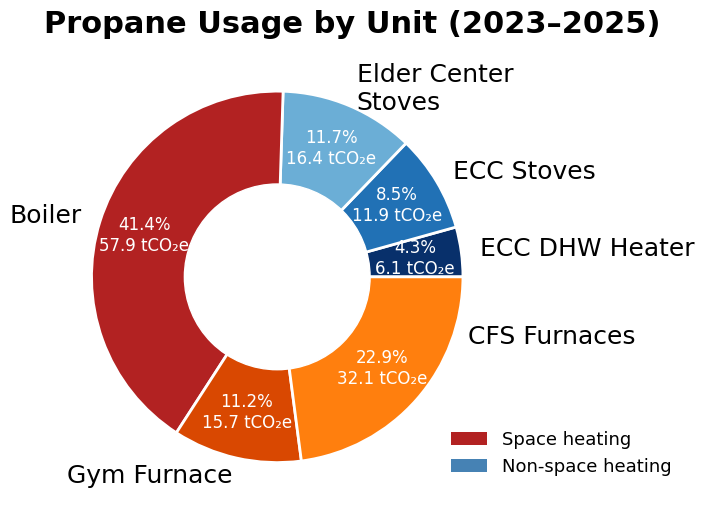

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# POSTER PIE CHART — Version A: tCO2e values INSIDE the slices
# ─────────────────────────────────────────────────────────────────────────────

def plot_poster_pie(
    selection="avg_2023_2025",
    controls_mode="fixed",
    save_path="poster_pie_chart.png",
    dpi=300,
):
    YEARS = [2023, 2024, 2025]
    GROUP_THRESHOLD_PCT = 4.0
    OTHER_COLOR = "#b0bec5"

    # ── 1. aggregate data ────────────────────────────────────────────────────
    if selection == "avg_2023_2025":
        pie_df = pie_df_all_years[pie_df_all_years["year"].isin(YEARS)].copy()
        pie_df = (
            pie_df.groupby(["unit_id", "device", "category"], as_index=False)
                  .agg(annual_gal=("annual_gal", "mean"))
        )
        title_suffix = "Average 2023–2025"
    else:
        pie_df = pie_df_all_years[pie_df_all_years["year"] == int(selection)].copy()
        title_suffix = str(selection)

    pie_df = _apply_controls_mode(pie_df, selection=selection, controls_mode=controls_mode)
    pie_df["annual_tco2e"] = pie_df["annual_gal"] * KGCO2E_PER_GAL_PROPANE / 1000.0

    total = float(pie_df["annual_tco2e"].sum())

    # ── 2. drop very small slices ────────────────────────────────────────────
    pie_df["pct"] = pie_df["annual_tco2e"] / total * 100.0
    plot_df = pie_df[pie_df["pct"] >= GROUP_THRESHOLD_PCT].copy()

    # ── 3. colors ────────────────────────────────────────────────────────────
    heating_palette = ["#b22222", "#d94801", "#ff7f0e", "#f4a261"]
    nonheating_palette = ["#08306b", "#2171b5", "#6baed6", "#9ecae1"]

    hi = ni = 0
    colors = []
    for _, row in plot_df.iterrows():
        if row["category"] == "heating":
            colors.append(heating_palette[hi % len(heating_palette)])
            hi += 1
        else:
            colors.append(nonheating_palette[ni % len(nonheating_palette)])
            ni += 1

    label_map = {
        "CFS Furnace 1, 2, & 3": "CFS Furnaces",
        "Elder Center Stove": "Elder Center\nStoves",
        "ECC Domestic Hot Water Heater": "ECC DHW Heater",
    }
    plot_df["device"] = plot_df["device"].replace(label_map)

    # ── 4. draw ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 7))
    fig.patch.set_facecolor("white")

    values = plot_df["annual_tco2e"].values
    slice_total = values.sum()

    def make_autopct(_):
        def _fmt(pct):
            val = pct / 100.0 * slice_total
            if pct < GROUP_THRESHOLD_PCT:
                return ""
            return f"{pct:.1f}%\n{val:.1f} tCO₂e"
        return _fmt

    wedges, texts, autotexts = ax.pie(
        values,
        labels=plot_df["device"].values,
        colors=colors,
        autopct=make_autopct(values),
        startangle=0,
        pctdistance=0.75,
        wedgeprops=dict(edgecolor="white", linewidth=2.0),
    )

    for t in texts:
        t.set_fontsize(18)
    for a in autotexts:
        a.set_fontsize(12)
        a.set_color("white")
        a.set_ha("center")

    for i, dev in enumerate(plot_df["device"]):
        if dev == "CFS Furnaces":
            x, y = texts[i].get_position()
            texts[i].set_position((x + 0.2, y + 0.4))

    # ── 5. center annotation ─────────────────────────────────────────────────
    ax.text(0, 0, f"{total:.0f}\ntCO₂e/yr",
            ha="center", va="center",
            fontsize=14, fontweight="bold", color="#333333",
            transform=ax.transData)

    centre = plt.Circle((0, 0), 0.5, color="white", zorder=10)
    ax.add_patch(centre)

    # ── 6. title + legend ────────────────────────────────────────────────────
    fig.suptitle(
        "Propane Usage by Unit (2023–2025)",
        fontsize=22,
        fontweight="bold",
        y=0.85,
    )

    from matplotlib.patches import Patch
    legend_els = [
        Patch(facecolor="firebrick", label="Space heating"),
        Patch(facecolor="steelblue", label="Non-space heating"),
    ]
    ax.legend(
        handles=legend_els,
        loc="center left",
        bbox_to_anchor=(0.84, 0.12),
        ncol=1,
        fontsize=13,
        frameon=False,
    )

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")
        print(f"Saved → {save_path}")
    plt.show()


plot_poster_pie(
    selection="avg_2023_2025",
    controls_mode="broken",
    save_path="poster_pie_chart_inside.png",
    dpi=300,
)

Saved → poster_pie_chart.png


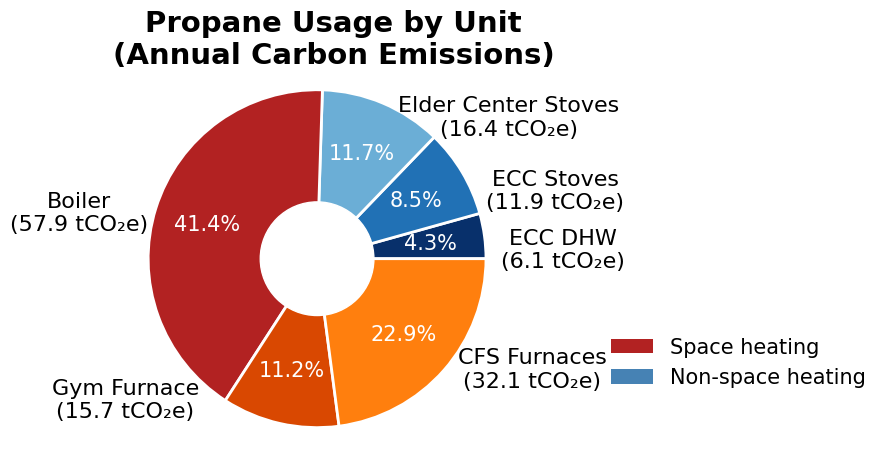

In [7]:
def plot_poster_pie(
    selection="avg_2023_2025",
    controls_mode="fixed",
    save_path="poster_pie_chart.png",
    dpi=300,
):
    YEARS = [2023, 2024, 2025]
    GROUP_THRESHOLD_PCT = 4.0

    # ── 1. aggregate data ────────────────────────────────────────────────────
    if selection == "avg_2023_2025":
        pie_df = pie_df_all_years[pie_df_all_years["year"].isin(YEARS)].copy()
        pie_df = (
            pie_df.groupby(["unit_id", "device", "category"], as_index=False)
            .agg(annual_gal=("annual_gal", "mean"))
        )
    else:
        pie_df = pie_df_all_years[pie_df_all_years["year"] == int(selection)].copy()

    pie_df = _apply_controls_mode(
        pie_df,
        selection=selection,
        controls_mode=controls_mode,
    )
    pie_df["annual_tco2e"] = pie_df["annual_gal"] * KGCO2E_PER_GAL_PROPANE / 1000.0
    total = float(pie_df["annual_tco2e"].sum())

    # ── 2. keep only meaningful slices ──────────────────────────────────────
    pie_df["pct"] = pie_df["annual_tco2e"] / total * 100.0
    plot_df = pie_df[pie_df["pct"] >= GROUP_THRESHOLD_PCT].copy()

    # ── 3. colors + labels ──────────────────────────────────────────────────
    heating_palette = ["#b22222", "#d94801", "#ff7f0e", "#f4a261"]
    nonheating_palette = ["#08306b", "#2171b5", "#6baed6", "#9ecae1"]

    hi = 0
    ni = 0
    colors = []
    for _, row in plot_df.iterrows():
        if row["category"] == "heating":
            colors.append(heating_palette[hi % len(heating_palette)])
            hi += 1
        else:
            colors.append(nonheating_palette[ni % len(nonheating_palette)])
            ni += 1

    label_map = {
        "CFS Furnace 1, 2, & 3": "CFS Furnaces",
        "Elder Center Stove": "Elder Center Stoves",
        "ECC Domestic Hot Water Heater": "ECC DHW",
    }
    plot_df["device"] = plot_df["device"].replace(label_map)

    composite_labels = [
        f"{dev}\n({val:.1f} tCO₂e)"
        for dev, val in zip(plot_df["device"].values, plot_df["annual_tco2e"].values)
    ]

    # ── 4. draw donut ───────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(13, 5))
    fig.patch.set_facecolor("white")

    wedges, texts, autotexts = ax.pie(
        plot_df["annual_tco2e"].values,
        labels=composite_labels,
        colors=colors,
        autopct=lambda p: f"{p:.1f}%" if p >= GROUP_THRESHOLD_PCT else "",
        startangle=0,
        pctdistance=0.68,
        labeldistance=1.15,
        radius=1.1,
        wedgeprops=dict(edgecolor="white", linewidth=2.0),
    )

    ax.set_aspect("equal")
    ax.set_xlim(-1.95, 1.95)
    ax.set_ylim(-1.35, 1.35)

    for t in texts:
        t.set_fontsize(16)
        t.set_ha("center")
        t.set_va("center")

    for a in autotexts:
        a.set_fontsize(15)
        a.set_color("white")

    # Push labels outward mostly in x, keep y a bit tighter
    custom_positions = {
        "Boiler": (-1.55, 0.30),
        "Gym Furnace": (-1.25, -0.92),
        "CFS Furnaces": (1.4, -0.72),
        "ECC DHW": (1.6, 0.06),
       "ECC Stoves": (1.55, 0.44),
       "Elder Center Stoves": (1.25, 0.92),
    }

    for i, dev in enumerate(plot_df["device"]):
        if dev in custom_positions:
            texts[i].set_position(custom_positions[dev])

    ax.text(
        0,
        0,
        f"{total:.0f}\ntCO₂e/yr",
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        color="#333333",
    )

    centre = plt.Circle((0, 0), 0.37, color="white", zorder=10)
    ax.add_patch(centre)

    fig.suptitle(
        "Propane Usage by Unit\n(Annual Carbon Emissions)",
        fontsize=21,
        fontweight="bold",
        y=0.93,
    )

    from matplotlib.patches import Patch

    legend_els = [
        Patch(facecolor="firebrick", label="Space heating"),
        Patch(facecolor="steelblue", label="Non-space heating"),
    ]
    ax.legend(
        handles=legend_els,
        loc="center left",
        bbox_to_anchor=(0.96, 0.25),
        ncol=1,
        fontsize=15,
        frameon=False,
    )

    plt.tight_layout(pad=0.6)

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")
        print(f"Saved → {save_path}")

    plt.show()


plot_poster_pie(
    selection="avg_2023_2025",
    controls_mode="broken",
    save_path="poster_pie_chart.png",
    dpi=300,
)

In [8]:
# Paste this whole cell into your notebook and run it after the pie bundle cell.
# This version matches the poster matplotlib pie formatting much more closely:
#   - same slice start geometry (start at 3 o'clock, counterclockwise)
#   - same labeldistance / pctdistance starting positions
#   - same CFS Furnaces label nudge
#   - same font sizes / colors / center text / legend styling
#   - same effective 7x7 poster pie area, with extra left margin for the legend
#
# In Colab / browser notebooks:
#   - Drag device labels, % labels, and the legend directly on the chart
#   - Use the camera icon to save the final PNG after dragging
#   - If you redraw, browser-side drag edits reset

import math
import sys
import subprocess
import importlib.util

import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML


def _ensure_package(pkg_name: str):
    if importlib.util.find_spec(pkg_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg_name])


_ensure_package("plotly")

import plotly.graph_objects as go
import plotly.io as pio

try:
    pio.renderers.default = "colab"
except Exception:
    pass


def launch_poster_style_dragdrop_pie():
    YEARS = [2023, 2024, 2025]
    GROUP_THRESHOLD_PCT = 4.0

    # Match matplotlib default look as closely as the browser allows.
    FONT_FAMILY = "DejaVu Sans, Arial, sans-serif"
    FIG_WIDTH = 880   # 700 px square pie area + left legend margin + small right margin
    FIG_HEIGHT = 740  # 700 px square pie area + top/bottom margins
    MARGIN_LEFT = 160
    MARGIN_RIGHT = 20
    MARGIN_TOP = 20
    MARGIN_BOTTOM = 20

    label_map = {
        "CFS Furnace 1, 2, & 3": "CFS Furnaces",
        "Elder Center Stove": "Elder Center Stoves",
        "ECC Domestic Hot Water Heater": "ECC DHW",
    }

    heating_palette = ["#b22222", "#d94801", "#ff7f0e", "#f4a261"]
    nonheating_palette = ["#08306b", "#2171b5", "#6baed6", "#9ecae1"]

    # Exact matplotlib-style manual nudge, in pie data coordinates.
    label_offsets = {
        "CFS Furnaces": (0.2, 0.4),
    }
    pct_offsets = {}

    year_dd = widgets.Dropdown(
        options=[
            ("2023", 2023),
            ("2024", 2024),
            ("2025", 2025),
            ("Average 2023–2025", "avg_2023_2025"),
        ],
        value="avg_2023_2025",
        description="Year:",
        style={"description_width": "55px"},
        layout=widgets.Layout(width="250px"),
    )

    controls_toggle = widgets.ToggleButtons(
        options=[("Broken controls", "broken"), ("Fixed controls", "fixed")],
        value="broken",
    )

    redraw_btn = widgets.Button(description="Redraw", layout=widgets.Layout(width="90px"))

    help_box = widgets.HTML(
        value=(
            "<div style='padding:8px 10px;border:1px solid #ddd;border-radius:6px;'>"
            "<b>Use:</b> drag device labels, % labels, or the legend directly on the chart. "
            "This version starts with poster-matched formatting. "
            "When the layout looks right, use the chart's <b>camera icon</b> to save the PNG."
            "</div>"
        )
    )

    status_box = widgets.HTML()
    display_handle = display(HTML("<div>Preparing chart…</div>"), display_id=True)

    def _build_plot_df(selection, controls_mode):
        """
        Mirror the poster cell's plotting prep as closely as possible so the
        initial slice geometry and text starting positions line up.
        """
        if selection == "avg_2023_2025":
            pie_df = pie_df_all_years[pie_df_all_years["year"].isin(YEARS)].copy()
            pie_df = (
                pie_df.groupby(["unit_id", "device", "category"], as_index=False)
                .agg(annual_gal=("annual_gal", "mean"))
            )
        else:
            pie_df = pie_df_all_years[pie_df_all_years["year"] == int(selection)].copy()

        pie_df = _apply_controls_mode(
            pie_df,
            selection=selection,
            controls_mode=controls_mode,
        ).copy()

        pie_df["annual_gal"] = pie_df["annual_gal"].astype(float)
        pie_df["annual_tco2e"] = pie_df["annual_gal"] * KGCO2E_PER_GAL_PROPANE / 1000.0

        total_all = float(pie_df["annual_tco2e"].sum())
        if total_all <= 0:
            return pd.DataFrame(columns=["device", "category", "annual_tco2e", "pct", "display_pct"]), 0.0, []

        # Match the poster cell: threshold based on total emissions.
        pie_df["pct"] = pie_df["annual_tco2e"] / total_all * 100.0
        plot_df = pie_df[pie_df["pct"] >= GROUP_THRESHOLD_PCT].copy()

        if plot_df.empty:
            return pd.DataFrame(columns=["device", "category", "annual_tco2e", "pct", "display_pct"]), total_all, []

        hi = 0
        ni = 0
        colors = []
        for _, row in plot_df.iterrows():
            if row["category"] == "heating":
                colors.append(heating_palette[hi % len(heating_palette)])
                hi += 1
            else:
                colors.append(nonheating_palette[ni % len(nonheating_palette)])
                ni += 1

        # Match the poster cell: rename after filtering/color assignment.
        plot_df["device"] = plot_df["device"].replace(label_map)

        # Match matplotlib autopct behavior: displayed percentages are based on
        # the displayed slices only.
        displayed_total = float(plot_df["annual_tco2e"].sum())
        plot_df["display_pct"] = plot_df["annual_tco2e"] / displayed_total * 100.0

        return plot_df.reset_index(drop=True), total_all, colors

    def _compute_positions(values, labeldistance=1.10, pctdistance=0.78, start_deg=0.0):
        """
        Compute matplotlib-like positions in pie data coordinates where the pie
        radius is 1.0, the first slice starts at 3 o'clock, and slices advance
        counterclockwise.
        """
        total = float(np.sum(values))
        if total <= 0:
            return []

        positions = []
        current_deg = start_deg
        for v in values:
            frac = float(v) / total
            span = frac * 360.0
            mid_deg = current_deg + span / 2.0
            theta = math.radians(mid_deg)

            lx = labeldistance * math.cos(theta)
            ly = labeldistance * math.sin(theta)
            px = pctdistance * math.cos(theta)
            py = pctdistance * math.sin(theta)

            positions.append(
                {
                    "label": (lx, ly),
                    "pct": (px, py),
                }
            )
            current_deg += span

        return positions

    def _make_figure(plot_df, total_all, colors):
        values = plot_df["annual_tco2e"].to_numpy(dtype=float)
        labels = plot_df["device"].tolist()
        pcts = plot_df["display_pct"].tolist()

        positions = _compute_positions(
            values=values,
            labeldistance=1.10,
            pctdistance=0.78,
            start_deg=0.0,
        )

        fig = go.Figure()

        # Main pie: full pie first, then overlay a white center circle to match
        # the matplotlib poster donut construction.
        fig.add_trace(
            go.Pie(
                labels=labels,
                values=values,
                sort=False,
                direction="counterclockwise",
                rotation=90,
                textinfo="none",
                hovertemplate="%{label}<br>%{value:.2f} tCO2e<extra></extra>",
                marker=dict(colors=colors, line=dict(color="white", width=2.0)),
                hole=0.0,
                showlegend=False,
                domain=dict(x=[0.0, 1.0], y=[0.0, 1.0]),
            )
        )

        # Dummy traces for a category-only legend.
        fig.add_trace(
            go.Scatter(
                x=[None],
                y=[None],
                mode="markers",
                marker=dict(size=14, color="firebrick", symbol="square"),
                name="Space heating",
                hoverinfo="skip",
                showlegend=True,
            )
        )
        fig.add_trace(
            go.Scatter(
                x=[None],
                y=[None],
                mode="markers",
                marker=dict(size=14, color="steelblue", symbol="square"),
                name="Non-space heating",
                hoverinfo="skip",
                showlegend=True,
            )
        )

        annotations = []
        for dev, pct, pos in zip(labels, pcts, positions):
            lx, ly = pos["label"]
            px, py = pos["pct"]

            dx, dy = label_offsets.get(dev, (0.0, 0.0))
            pdx, pdy = pct_offsets.get(dev, (0.0, 0.0))

            annotations.append(
                dict(
                    x=lx + dx,
                    y=ly + dy,
                    xref="x",
                    yref="y",
                    text=dev,
                    showarrow=False,
                    font=dict(family=FONT_FAMILY, size=18, color="#000000"),
                    xanchor="center",
                    yanchor="middle",
                    align="center",
                    bgcolor="rgba(255,255,255,0.0)",
                )
            )
            annotations.append(
                dict(
                    x=px + pdx,
                    y=py + pdy,
                    xref="x",
                    yref="y",
                    text=f"{pct:.1f}%",
                    showarrow=False,
                    font=dict(family=FONT_FAMILY, size=14, color="white"),
                    xanchor="center",
                    yanchor="middle",
                    align="center",
                    bgcolor="rgba(0,0,0,0.0)",
                )
            )

        # Center text, matching the poster wording/style.
        annotations.append(
            dict(
                x=0.0,
                y=0.0,
                xref="x",
                yref="y",
                text=f"<b>Total:</b><br>~{total_all:.0f} tCO₂e/yr",
                showarrow=False,
                font=dict(family=FONT_FAMILY, size=14, color="#333333"),
                xanchor="center",
                yanchor="middle",
                align="center",
            )
        )

        fig.update_layout(
            annotations=annotations,
            shapes=[
                dict(
                    type="circle",
                    xref="x",
                    yref="y",
                    x0=-0.5,
                    y0=-0.5,
                    x1=0.5,
                    y1=0.5,
                    fillcolor="white",
                    line=dict(color="white", width=1),
                    layer="above",
                )
            ],
            width=FIG_WIDTH,
            height=FIG_HEIGHT,
            autosize=False,
            paper_bgcolor="white",
            plot_bgcolor="white",
            margin=dict(l=MARGIN_LEFT, r=MARGIN_RIGHT, t=MARGIN_TOP, b=MARGIN_BOTTOM),
            font=dict(family=FONT_FAMILY, color="#000000"),
            showlegend=True,
            legend=dict(
                x=-0.30,
                y=1.0,
                xanchor="left",
                yanchor="top",
                bgcolor="rgba(255,255,255,0.0)",
                bordercolor="rgba(0,0,0,0.0)",
                borderwidth=0,
                font=dict(family=FONT_FAMILY, size=15, color="#000000"),
                orientation="v",
                traceorder="normal",
            ),
            xaxis=dict(
                range=[-1.35, 1.35],
                visible=False,
                showgrid=False,
                zeroline=False,
                fixedrange=True,
                constrain="domain",
            ),
            yaxis=dict(
                range=[-1.35, 1.35],
                visible=False,
                showgrid=False,
                zeroline=False,
                fixedrange=True,
                scaleanchor="x",
                scaleratio=1,
                constrain="domain",
            ),
        )

        return fig

    def _render(_=None):
        try:
            plot_df, total_all, colors = _build_plot_df(year_dd.value, controls_toggle.value)

            if total_all <= 0 or plot_df.empty:
                status_box.value = "<div style='color:#b00020; padding:6px 0;'>No data available for this selection.</div>"
                display_handle.update(HTML("<div style='padding:16px;border:1px solid #ddd;background:white;'>No chart data available.</div>"))
                return

            fig = _make_figure(plot_df, total_all, colors)
            html = fig.to_html(
                full_html=False,
                include_plotlyjs="cdn",
                config={
                    "editable": True,
                    "edits": {
                        "annotationPosition": True,
                        "legendPosition": True,
                        "annotationText": False,
                        "legendText": False,
                        "titleText": False,
                    },
                    "displaylogo": False,
                    "responsive": False,
                    "toImageButtonOptions": {
                        "format": "png",
                        "filename": f"poster_pie_{year_dd.value}_{controls_toggle.value}",
                        "scale": 3,
                    },
                },
            )

            wrapped_html = f"""
            <div style=\"width:{FIG_WIDTH}px; min-height:{FIG_HEIGHT}px; background:white;\">{html}</div>
            """
            display_handle.update(HTML(wrapped_html))

            shown_total = float(plot_df["annual_tco2e"].sum())
            hidden_total = total_all - shown_total
            mode_lbl = "Broken controls" if controls_toggle.value == "broken" else "Fixed controls"
            status_box.value = (
                f"<div style='color:#2e7d32; padding:6px 0;'>"
                f"Rendered {len(plot_df)} slices | shown = {shown_total:.2f} tCO2e | "
                f"total = {total_all:.2f} tCO2e | hidden small slices = {hidden_total:.2f} tCO2e "
                f"({mode_lbl})"
                f"</div>"
            )
        except Exception as e:
            status_box.value = f"<div style='color:#b00020; padding:6px 0;'><b>Render failed:</b> {type(e).__name__}: {e}</div>"
            display_handle.update(
                HTML(
                    f"<pre style='white-space:pre-wrap; border:1px solid #ddd; padding:12px; background:#fff8f8;'>"
                    f"Render failed:\n{type(e).__name__}: {e}</pre>"
                )
            )

    year_dd.observe(_render, names="value")
    controls_toggle.observe(_render, names="value")
    redraw_btn.on_click(_render)

    display(
        widgets.VBox([
            widgets.HBox([year_dd, controls_toggle, redraw_btn]),
            help_box,
            status_box,
        ])
    )

    _render()

In [9]:
# Run this after the cell is defined:
launch_poster_style_dragdrop_pie()

Saved → poster_pie_chart.png


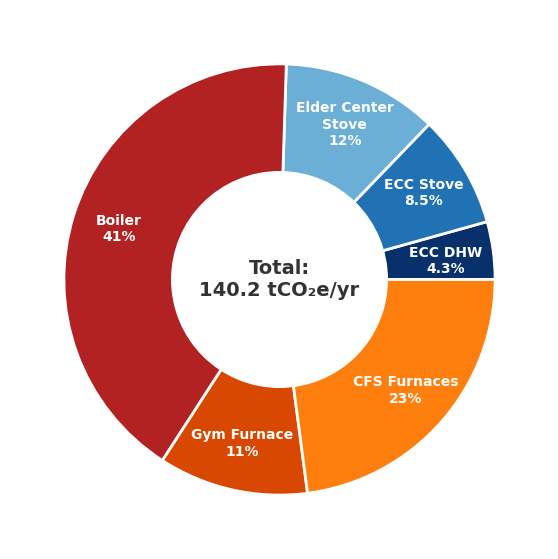

<Figure size 640x480 with 0 Axes>

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# POSTER PIE CHART  — drop-in cell, run after pie bundle is loaded
# Uses: pie_df_all_years, warm_colors, cool_colors, KGCO2E_PER_GAL_PROPANE
#       boiler_fixed_controls_annual_gal, boiler_unit_id
# Output: saves poster_pie_chart.png to working directory
# ─────────────────────────────────────────────────────────────────────────────

def plot_poster_pie(
    selection="avg_2023_2025",
    controls_mode="fixed",
    save_path="poster_pie_chart.png",
    dpi=300,
):
    YEARS = [2023, 2024, 2025]
    GROUP_THRESHOLD_PCT = 4.0        # slices below this get collapsed into "Other"
    OTHER_COLOR = "#b0bec5"

    # ── 1. aggregate data (mirrors your existing logic) ──────────────────────
    if selection == "avg_2023_2025":
        pie_df = pie_df_all_years[pie_df_all_years["year"].isin(YEARS)].copy()
        pie_df = (
            pie_df.groupby(["unit_id", "device", "category"], as_index=False)
                  .agg(annual_gal=("annual_gal", "mean"))
        )
        title_suffix = "Average 2023–2025"
    else:
        pie_df = pie_df_all_years[pie_df_all_years["year"] == int(selection)].copy()
        title_suffix = str(selection)

    pie_df = _apply_controls_mode(pie_df, selection=selection, controls_mode=controls_mode)
    pie_df["annual_tco2e"] = pie_df["annual_gal"] * KGCO2E_PER_GAL_PROPANE / 1000.0

    total = float(pie_df["annual_tco2e"].sum())

    # ── 2. drop very small slices entirely ───────────────────────────────────
    pie_df["pct"] = pie_df["annual_tco2e"] / total * 100.0
    plot_df = pie_df[pie_df["pct"] >= GROUP_THRESHOLD_PCT].copy()

    # ── 3. colors ────────────────────────────────────────────────────────────
    heating_palette = ["#b22222", "#d94801", "#ff7f0e", "#f4a261"]
    nonheating_palette = ["#08306b", "#2171b5", "#6baed6", "#9ecae1"]

    hi = ni = 0
    colors = []
    for _, row in plot_df.iterrows():
        if row["category"] == "heating":
            colors.append(heating_palette[hi % len(heating_palette)])
            hi += 1
        else:
            colors.append(nonheating_palette[ni % len(nonheating_palette)])
            ni += 1

    label_map = {
        "CFS Furnace 1, 2, & 3": "CFS Furnaces",
        "Elder Center Stove": "Elder Center\nStove",
        "ECC Domestic Hot Water Heater": "ECC DHW",
        "ECC Stoves": "ECC Stove",
    }

    plot_df["device"] = plot_df["device"].replace(label_map)

    # ── 4. draw ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 7))
    fig.patch.set_facecolor("white")

    # Create custom autopct function to stack labels and percentages
    devices = plot_df["device"].values
    device_idx = [0]

    def custom_autopct(p):
        idx = device_idx[0]
        device_idx[0] += 1
        if p >= GROUP_THRESHOLD_PCT:
            return f"{devices[idx]}\n{p:.2g}%"
        return ""

    wedges, texts, autotexts = ax.pie(
        plot_df["annual_tco2e"].values,
        labels=None,
        colors=colors,
        autopct=custom_autopct,
        startangle=0,
        pctdistance=0.78,
        wedgeprops=dict(edgecolor="white", linewidth=2.0),
    )

    # Make all text white, bold, and same font size
    for a in autotexts:
        a.set_fontsize(10)
        a.set_color("white")
        a.set_fontweight('bold')

    # Adjust ECC DHW label position down slightly
    for i, autotext in enumerate(autotexts):
        if "ECC DHW" in autotext.get_text():
            x, y = autotext.get_position()
            autotext.set_position((x, y - 0.02))

    # ── 5. center annotation: total ──────────────────────────────────────────
    # hollow center circle → donut
    centre = plt.Circle((0, 0), 0.5, color="white", zorder=10)
    ax.add_patch(centre)

    # center annotation: cumulative propane emissions
    ax.text(
        0, 0,
        f"Total:\n{total:.1f} tCO₂e/yr",
        ha="center", va="center",
        fontsize=14, fontweight="bold", color="#333333",
        zorder=11,
    )

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white", pad_inches=0.00)
        print(f"Saved → {save_path}")
    plt.show()
    plt.tight_layout()

plot_poster_pie(
    selection="avg_2023_2025",
    controls_mode="broken",
    save_path="poster_pie_chart.png",
    dpi=300,
)

In [11]:
def print_usage_table(
    selection="avg_2023_2025",
    controls_mode="fixed",
):
    """Print table of unit, avg usage (gal), and avg emissions (tCO2e)."""
    YEARS = [2023, 2024, 2025]

    # ── aggregate data (mirrors pie chart logic) ──────────────────────────────
    if selection == "avg_2023_2025":
        pie_df = pie_df_all_years[pie_df_all_years["year"].isin(YEARS)].copy()
        pie_df = (
            pie_df.groupby(["unit_id", "device", "category"], as_index=False)
                  .agg(annual_gal=("annual_gal", "mean"))
        )
    else:
        pie_df = pie_df_all_years[pie_df_all_years["year"] == int(selection)].copy()

    pie_df = _apply_controls_mode(pie_df, selection=selection, controls_mode=controls_mode)
    pie_df["annual_tco2e"] = pie_df["annual_gal"] * KGCO2E_PER_GAL_PROPANE / 1000.0

    # ── group by unit and sum ────────────────────────────────────────────────
    summary = pie_df.groupby("unit_id", as_index=False).agg(
        annual_gal=("annual_gal", "sum"),
        annual_tco2e=("annual_tco2e", "sum")
    ).sort_values("unit_id")

    # ── print table ──────────────────────────────────────────────────────────
    print("\n" + "="*75)
    print(f"{'USAGE SUMMARY':^75}")
    print(f"{'Selection: ' + selection:^75}")
    print("="*75)
    print(f"{'Unit':<25} {'Usage (gal)':<25} {'Emissions (tCO₂e)':<25}")
    print("-"*75)
    for _, row in summary.iterrows():
        print(f"{row['unit_id']:<25} {row['annual_gal']:>23.1f} {row['annual_tco2e']:>23.1f}")
    print("-"*75)
    total_gal = summary["annual_gal"].sum()
    total_tco2e = summary["annual_tco2e"].sum()
    print(f"{'TOTAL':<25} {total_gal:>23.1f} {total_tco2e:>23.1f}")
    print("="*75 + "\n")

    return summary


# Run with same parameters as your pie chart
usage_df = print_usage_table(
    selection="avg_2023_2025",
    controls_mode="broken",
)


                               USAGE SUMMARY                               
                         Selection: avg_2023_2025                          
Unit                      Usage (gal)               Emissions (tCO₂e)        
---------------------------------------------------------------------------
admin_stove                                  33.9                     0.2
ecc_dhw_heater                             1058.4                     6.1
ecc_stove                                  2072.8                    11.9
elder_stove                                2863.5                    16.4
unit_1                                    10122.4                    57.9
unit_2                                     2745.0                    15.7
unit_3                                     5609.4                    32.1
---------------------------------------------------------------------------
TOTAL                                     24505.4                   140.2

